# TP NOTÉ S3 — REGRESSION ENGINEERING CHALLENGE
## 4e année Option Développeur — 3 h — Ames Housing, Iowa (USA)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Contexte & dataset — 5 pts

Vous intervenez pour une équipe qui doit estimer le **prix de vente de logements à Ames, Iowa**. Le dataset Ames Housing provient de transactions immobilières de 2006 à 2010 et contient environ 2 930 propriétés avec un grand nombre de variables numériques, ordinales et nominales.

**Cible : `SalePrice`.**

Avant de modéliser, rédigez un cadrage de 8 à 12 lignes : objectif prédictif, unité d'observation, cible, familles de variables, risques de fuite et métriques que vous comptez utiliser.

Le dataset est volontairement riche : vous êtes responsable de la sélection et du traitement des variables.

In [13]:
# Cadrage du problème
# L'objectif est de prédire le prix de vente de logements situés à Ames, dans l'Iowa.
# Chaque ligne représente une propriété immobilière.
# La variable cible est `SalePrice`, qui est une variable numérique continue.
# Les variables explicatives décrivent la surface, la qualité, l'année de construction,
# les équipements, le garage, le sous-sol et la localisation du logement.
# Il s'agit d'un problème de régression supervisée.
# Les variables numériques et catégorielles seront traitées avec des pipelines différents.
# Les valeurs manquantes doivent être étudiées car elles peuvent représenter l'absence
# d'un équipement plutôt qu'une information inconnue.
# Les principaux risques de fuite sont d'apprendre les imputations ou les paramètres
# de transformation sur les jeux de validation et de test.
# Le jeu de données sera séparé en TRAIN, VALIDATION et TEST.
# Les performances seront évaluées avec la MSE, la RMSE et le R².
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

ames = fetch_openml(
    name="ames_housing",
    as_frame=True,
    parser="auto"
)

df = ames.frame.copy()

df.shape

(2930, 81)

In [11]:
"SalePrice" in df.columns

False

In [12]:
[colonne for colonne in df.columns if "Sale" in colonne]

['Sale_Type', 'Sale_Condition', 'Sale_Price']

In [16]:
df

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude
0,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,141,31770,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Average,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112,Typical,Typical,CBlock,Typical,Good,Gd,BLQ,2,Unf,0,441,1080,GasA,Fair,Y,SBrkr,1656,0,0,1656,1,0,1,0,3,1,Typical,7,Typ,2,Good,Attchd,Fin,2,528,Typical,Typical,Partial_Pavement,210,62,0,0,0,0,No_Pool,No_Fence,None,0,5,2010,WD,Normal,215000,-93.619754,42.054035
1,One_Story_1946_and_Newer_All_Styles,Residential_High_Density,80,11622,Pave,No_Alley_Access,Regular,Lvl,AllPub,Inside,Gtl,North_Ames,Feedr,Norm,OneFam,One_Story,Average,Above_Average,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0,Typical,Typical,CBlock,Typical,Typical,No,Rec,6,LwQ,144,270,882,GasA,Typical,Y,SBrkr,896,0,0,896,0,0,1,0,2,1,Typical,5,Typ,0,No_Fireplace,Attchd,Unf,1,730,Typical,Typical,Paved,140,0,0,0,120,0,No_Pool,Minimum_Privacy,None,0,6,2010,WD,Normal,105000,-93.619756,42.053014
2,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,81,14267,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Above_Average,Above_Average,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108,Typical,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,406,1329,GasA,Typical,Y,SBrkr,1329,0,0,1329,0,0,1,1,3,1,Good,6,Typ,0,No_Fireplace,Attchd,Unf,1,312,Typical,Typical,Paved,393,36,0,0,0,0,No_Pool,No_Fence,Gar2,12500,6,2010,WD,Normal,172000,-93.619387,42.052659
3,One_Story_1946_and_Newer_All_Styles,Residential_Low_Density,93,11160,Pave,No_Alley_Access,Regular,Lvl,AllPub,Corner,Gtl,North_Ames,Norm,Norm,OneFam,One_Story,Good,Average,1968,1968,Hip,CompShg,BrkFace,BrkFace,None,0,Good,Typical,CBlock,Typical,Typical,No,ALQ,1,Unf,0,1045,2110,GasA,Excellent,Y,SBrkr,2110,0,0,2110,1,0,2,1,3,1,Excellent,8,Typ,2,Typical,Attchd,Fin,2,522,Typical,Typical,Paved,0,0,0,0,0,0,No_Pool,No_Fence,None,0,4,2010,WD,Normal,244000,-93.617320,42.051245
4,Two_Story_1946_and_Newer,Residential_Low_Density,74,13830,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,OneFam,Two_Story,Average,Average,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0,Typical,Typical,PConc,Good,Typical,No,GLQ,3,Unf,0,137,928,GasA,Good,Y,SBrkr,928,701,0,1629,0,0,2,1,3,1,Typical,6,Typ,1,Typical,Attchd,Fin,2,482,Typical,Typical,Paved,212,34,0,0,0,0,No_Pool,Minimum_Privacy,None,0,3,2010,WD,Normal,189900,-93.638933,42.060899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,Split_or_Multilevel,Residential_Low_Density,37,7937,Pave,No_Alley_Access,Slightly_Irregular,Lvl,AllPub,CulDSac,Gtl,Mitchell,Norm,Norm,OneFam,SLvl,Above_Average,Above_Average,1984,1984,Gable,CompShg,HdBoard,HdBoard,None,0,Typical,Typical,CBlo

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   MS_SubClass         2930 non-null   category
 1   MS_Zoning           2930 non-null   category
 2   Lot_Frontage        2930 non-null   int64   
 3   Lot_Area            2930 non-null   int64   
 4   Street              2930 non-null   category
 5   Alley               2930 non-null   category
 6   Lot_Shape           2930 non-null   category
 7   Land_Contour        2930 non-null   category
 8   Utilities           2930 non-null   category
 9   Lot_Config          2930 non-null   category
 10  Land_Slope          2930 non-null   category
 11  Neighborhood        2930 non-null   category
 12  Condition_1         2930 non-null   category
 13  Condition_2         2930 non-null   category
 14  Bldg_Type           2930 non-null   category
 15  House_Style         2930 non-null   category
 16 

In [3]:
df.columns.tolist()

['MS_SubClass',
 'MS_Zoning',
 'Lot_Frontage',
 'Lot_Area',
 'Street',
 'Alley',
 'Lot_Shape',
 'Land_Contour',
 'Utilities',
 'Lot_Config',
 'Land_Slope',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod_Add',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Mas_Vnr_Area',
 'Exter_Qual',
 'Exter_Cond',
 'Foundation',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_SF_1',
 'BsmtFin_Type_2',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 'Heating',
 'Heating_QC',
 'Central_Air',
 'Electrical',
 'First_Flr_SF',
 'Second_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'Kitchen_Qual',
 'TotRms_AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace_Qu',
 'Garage_Type',
 'Garage_Finish',
 'Garage_Cars',
 'Garage_Area',
 'Garage_Qual',
 'Garage

## Audit orienté modélisation — 15 pts

Sans produire une EDA encyclopédique, établissez les diagnostics nécessaires à une régression fiable.

Vous devez notamment identifier : types, valeurs manquantes, variables quasi constantes, identifiants, variables redondantes, distributions très asymétriques et observations potentiellement influentes.

**Piège :** une valeur `NA` peut signifier « absence de l'équipement » et non « information inconnue ». Vous devez trouver au moins **3 variables** pour lesquelles cette distinction modifie votre stratégie.

Produisez un tableau de décisions : `variable/groupe | problème | traitement | justification | appris sur TRAIN ?`.

In [78]:
# Votre travail expérimental ici
"SalePrice" in df.columns

False

In [15]:
"SalePrice" in df.columns
[colonne for colonne in df.columns if "Sale" in colonne]

['Sale_Type', 'Sale_Condition', 'Sale_Price']

In [17]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MS_SubClass,2930,16,One_Story_1946_and_Newer_All_Styles,1079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MS_Zoning,2930,7,Residential_Low_Density,2273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot_Frontage,2930.0,NaN,NaN,NaN,57.647782,33.499441,0.0,43.0,63.0,78.0,313.0
Lot_Area,2930.0,NaN,NaN,NaN,10147.921843,7880.017759,1300.0,7440.25,9436.5,11555.25,215245.0
Street,2930,2,Pave,2918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,2930,3,No_Alley_Access,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot_Shape,2930,4,Regular,1859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Land_Contour,2930,4,Lvl,2633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utilities,2930,3,AllPub,2927,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot_Config,2930,5,Inside,2140,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
## Audit orienté modélisation

# La base contient 2930 observations et 81 variables.

# La variable cible est `Sale_Price`, qui correspond au prix de vente du logement.

# Les variables explicatives sont numériques ou catégorielles. Elles décrivent
# notamment la surface, la qualité du logement, l'année de construction, les
# équipements, le garage, le sous-sol et la localisation.

# L'audit porte sur les valeurs manquantes, les identifiants, les variables presque
# constantes, les variables redondantes, les distributions asymétriques et les
# observations potentiellement influentes.

# Cette étape est réalisée avant la modélisation afin de définir les traitements
# nécessaires sans modifier prématurément les données.

audit_na = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "nombre_NA": df.isna().sum(),
    "pourcentage_NA": (
        df.isna().mean() * 100
    ).round(2),
    "valeurs_uniques": df.nunique(dropna=True)
})

audit_na = audit_na.sort_values(
    by="pourcentage_NA",
    ascending=False
)

audit_na

,type,nombre_NA,pourcentage_NA,valeurs_uniques
MS_SubClass,category,0,0.0,16
MS_Zoning,category,0,0.0,7
Lot_Frontage,int64,0,0.0,129
Lot_Area,int64,0,0.0,1960
Street,category,0,0.0,2
Alley,category,0,0.0,3
Lot_Shape,category,0,0.0,4
Land_Contour,category,0,0.0,4
Utilities,category,0,0.0,3
Lot_Config,category,0,0.0,5


In [33]:
nombre_total_na = df.isna().sum().sum()

nombre_total_na
#On constate que l'on a pas de cellules vides. 

np.int64(0)

In [32]:
df[df.isna().any(axis=1)]

,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Year_Sold,Sale_Type,Sale_Condition,Sale_Price,Longitude,Latitude


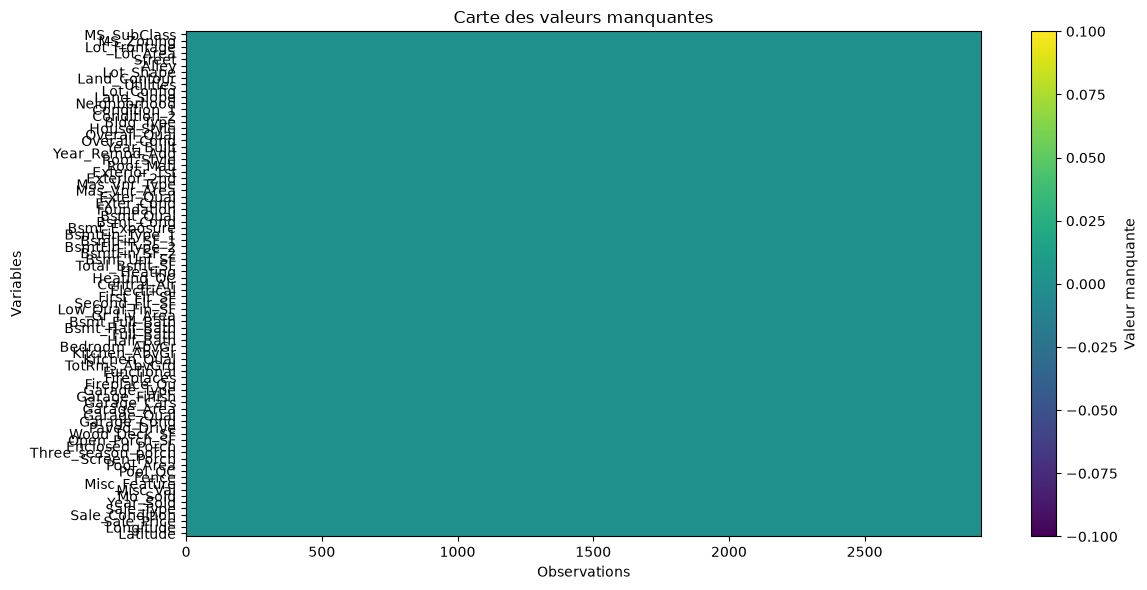

In [37]:
plt.figure(figsize=(12, 6))

plt.imshow(
    df.isna().T,
    aspect="auto",
    cmap="viridis",
    interpolation="nearest"
)

plt.yticks(
    range(len(df.columns)),
    df.columns
)

plt.xlabel("Observations")
plt.ylabel("Variables")
plt.title("Carte des valeurs manquantes")
plt.colorbar(label="Valeur manquante")
plt.tight_layout()
plt.show()

In [40]:
pd.DataFrame({
    "indicateur": [
        "Colonnes contenant au moins un NA",
        "Nombre total de NA",
        "Lignes contenant au moins un NA"
    ],
    "valeur": [
        (df.isna().sum() > 0).sum(),
        df.isna().sum().sum(),
        df.isna().any(axis=1).sum()
    ]
})

# Résultat de l'analyse des valeurs manquantes

# La commande `df.isna().sum()` indique zéro valeur manquante pour toutes les
# variables. Le nombre total de valeurs manquantes est donc égal à zéro.

# La carte des valeurs manquantes ne montre aucune valeur absente dans la version
# du dataset utilisée.

# Cette version récupérée depuis OpenML est déjà préparée ou ne conserve pas les
# valeurs manquantes originales du dataset Ames Housing brut.

# Il n'est donc pas possible d'estimer expérimentalement une stratégie d'imputation
# sur cette version. Le pipeline conservera néanmoins un `SimpleImputer` afin de
# rester robuste à de futures données incomplètes.

# Cette absence de valeurs manquantes constitue une limite du dataset utilisé pour
# l'analyse, car elle empêche d'étudier la distinction entre absence d'équipement
# et information inconnue.

,indicateur,valeur
0,Colonnes contenant au moins un NA,0
1,Nombre total de NA,0
2,Lignes contenant au moins un NA,0


In [41]:
colonnes_identifiants = [
    colonne
    for colonne in df.columns
    if (
        "id" in colonne.lower()
        or colonne.lower() in [
            "order",
            "pid"
        ]
    )
]

colonnes_identifiants

[]

In [43]:
df.columns.tolist()

['MS_SubClass',
 'MS_Zoning',
 'Lot_Frontage',
 'Lot_Area',
 'Street',
 'Alley',
 'Lot_Shape',
 'Land_Contour',
 'Utilities',
 'Lot_Config',
 'Land_Slope',
 'Neighborhood',
 'Condition_1',
 'Condition_2',
 'Bldg_Type',
 'House_Style',
 'Overall_Qual',
 'Overall_Cond',
 'Year_Built',
 'Year_Remod_Add',
 'Roof_Style',
 'Roof_Matl',
 'Exterior_1st',
 'Exterior_2nd',
 'Mas_Vnr_Type',
 'Mas_Vnr_Area',
 'Exter_Qual',
 'Exter_Cond',
 'Foundation',
 'Bsmt_Qual',
 'Bsmt_Cond',
 'Bsmt_Exposure',
 'BsmtFin_Type_1',
 'BsmtFin_SF_1',
 'BsmtFin_Type_2',
 'BsmtFin_SF_2',
 'Bsmt_Unf_SF',
 'Total_Bsmt_SF',
 'Heating',
 'Heating_QC',
 'Central_Air',
 'Electrical',
 'First_Flr_SF',
 'Second_Flr_SF',
 'Low_Qual_Fin_SF',
 'Gr_Liv_Area',
 'Bsmt_Full_Bath',
 'Bsmt_Half_Bath',
 'Full_Bath',
 'Half_Bath',
 'Bedroom_AbvGr',
 'Kitchen_AbvGr',
 'Kitchen_Qual',
 'TotRms_AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace_Qu',
 'Garage_Type',
 'Garage_Finish',
 'Garage_Cars',
 'Garage_Area',
 'Garage_Qual',
 'Garage

In [ ]:
# Résultat de l'identification des identifiants

# Aucune colonne identifiante n'a été détectée automatiquement dans la version
# OpenML utilisée : `colonnes_identifiants` retourne une liste vide.

# Les colonnes `PID` et `Order`, présentes dans la version brute `ames_raw`, ont
# probablement déjà été supprimées dans cette version prétraitée.

# Aucune colonne supplémentaire n'est donc retirée à cette étape.

In [44]:
identifiants_audit = pd.DataFrame({
    colonne: {
        "valeurs_uniques": df[colonne].nunique(
            dropna=False
        ),
        "nombre_lignes": len(df),
        "ratio_unique": round(
            df[colonne].nunique(
                dropna=False
            ) / len(df),
            3
        )
    }
    for colonne in colonnes_identifiants
}).T

identifiants_audit

""


In [46]:
X = df.drop(
    columns=["Sale_Price"]
)

y = df["Sale_Price"]

X = X.drop(
    columns=colonnes_identifiants,
    errors="ignore"
)

X.shape, y.shape

((2930, 80), (2930,))

In [47]:
cardinalites = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_uniques": df.nunique(
        dropna=False
    ),
    "nombre_lignes": len(df)
})

cardinalites["ratio_valeurs_uniques"] = (
    cardinalites["valeurs_uniques"]
    / cardinalites["nombre_lignes"]
)

cardinalites.sort_values(
    by="valeurs_uniques"
).head(20)

,type,valeurs_uniques,nombre_lignes,ratio_valeurs_uniques
Street,category,2,2930,0.000683
Central_Air,category,2,2930,0.000683
Land_Slope,category,3,2930,0.001024
Alley,category,3,2930,0.001024
Half_Bath,int64,3,2930,0.001024
Paved_Drive,category,3,2930,0.001024
Bsmt_Half_Bath,int64,3,2930,0.001024
Utilities,category,3,2930,0.001024
Land_Contour,category,4,2930,0.001365
Bsmt_Full_Bath,int64,4,2930,0.001365


In [48]:
dominance = []

for colonne in df.columns:
    proportions = (
        df[colonne]
        .value_counts(
            dropna=False,
            normalize=True
        )
    )

    dominance.append({
        "variable": colonne,
        "modalite_principale": proportions.index[0],
        "proportion_principale": proportions.iloc[0]
    })

dominance = pd.DataFrame(
    dominance
)

dominance.sort_values(
    by="proportion_principale",
    ascending=False
).head(20)

,variable,modalite_principale,proportion_principale
8,Utilities,AllPub,0.998976
4,Street,Pave,0.995904
70,Pool_QC,No_Pool,0.995563
69,Pool_Area,0,0.995563
13,Condition_2,Norm,0.989761
67,Three_season_porch,0,0.987372
44,Low_Qual_Fin_SF,0,0.986348
21,Roof_Matl,CompShg,0.985324
38,Heating,GasA,0.984642
73,Misc_Val,0,0.964846


In [49]:
variables_quasi_constantes = dominance[
    dominance["proportion_principale"] >= 0.95
]

variables_quasi_constantes

,variable,modalite_principale,proportion_principale
4,Street,Pave,0.995904
8,Utilities,AllPub,0.998976
10,Land_Slope,Gtl,0.951877
13,Condition_2,Norm,0.989761
21,Roof_Matl,CompShg,0.985324
38,Heating,GasA,0.984642
44,Low_Qual_Fin_SF,0,0.986348
51,Kitchen_AbvGr,1,0.954266
67,Three_season_porch,0,0.987372
69,Pool_Area,0,0.995563


In [50]:
# Variables quasi constantes

# Les variables quasi constantes sont des variables pour lesquelles une seule
# modalité représente une très grande proportion des observations.

# Elles contiennent généralement peu d'information discriminante pour la prédiction.
# Elles sont donc examinées individuellement avant toute suppression.

# Une variable n'est pas supprimée uniquement sur la base d'un seuil statistique.
# La décision tient également compte de sa signification métier et de son intérêt
# potentiel pour prédire `Sale_Price`.

In [51]:
colonnes_numeriques_audit = df.select_dtypes(
    include=np.number
).columns.tolist()

correlations = df[
    colonnes_numeriques_audit
].corr()

correlations.round(2)

,Lot_Frontage,Lot_Area,Year_Built,Year_Remod_Add,Mas_Vnr_Area,BsmtFin_SF_1,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Cars,Garage_Area,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,Three_season_porch,Screen_Porch,Pool_Area,Misc_Val,Mo_Sold,Year_Sold,Sale_Price,Longitude,Latitude
Lot_Frontage,1.00,0.14,0.03,0.07,0.11,0.07,-0.01,0.14,0.21,0.24,-0.00,0.02,0.19,0.02,-0.03,0.08,-0.03,0.11,0.02,0.20,0.05,0.14,0.19,0.00,0.09,0.02,0.00,0.05,0.11,0.00,0.02,-0.01,0.20,-0.02,0.05
Lot_Area,0.14,1.00,0.02,0.02,0.13,-0.05,0.08,0.02,0.25,0.33,0.03,0.00,0.29,0.12,0.03,0.13,0.04,0.14,-0.02,0.22,0.26,0.18,0.21,0.16,0.10,0.02,0.02,0.06,0.09,0.07,0.00,-0.02,0.27,-0.10,-0.04
Year_Built,0.03,0.02,1.00,0.61,0.31,-0.18,-0.03,0.13,0.41,0.31,0.02,-0.14,0.24,0.21,-0.03,0.47,0.27,-0.06,-0.14,0.11,0.17,0.54,0.48,0.23,0.20,-0.37,0.02,-0.04,0.00,-0.01,0.01,-0.01,0.56,-0.43,0.25
Year_Remod_Add,0.07,0.02,0.61,1.00,0.19,-0.05,-0.06,0.17,0.30,0.24,0.16,-0.06,0.32,0.13,-0.05,0.46,0.21,-0.02,-0.14,0.20,0.13,0.42,0.38,0.22,0.24,-0.22,0.04,-0.05,-0.01,-0.00,0.02,0.03,0.53,-0.32,0.18
Mas_Vnr_Area,0.11,0.13,0.31,0.19,1.00,-0.11,-0.01,0.09,0.39,0.39,0.12,-0.06,0.40,0.14,0.02,0.25,0.19,0.08,-0.05,0.28,0.27,0.36,0.37,0.17,0.14,-0.11,0.01,0.07,0.00,0.05,-0.00,-0.02,0.50,-0.08,0.22
BsmtFin_SF_1,0.07,-0.05,-0.18,-0.05,-0.11,1.00,-0.12,0.49,-0.16,-0.12,0.16,0.07,0.05,-0.47,-0.11,0.05,0.03,0.11,0.10,0.11,-0.14,-0.08,-0.10,-0.15,-0.00,0.10,-0.05,-0.04,-0.03,-0.04,0.02,-0.04,-0.13,0.06,0.01
BsmtFin_SF_2,-0.01,0.08,-0.03,-0.06,-0.01,-0.12,1.00,-0.24,0.09,0.08,-0.10,-0.00,-0.02,0.16,0.10,-0.08,-0.03,-0.03,-0.04,-0.05,0.07,-0.01,0.00,0.10,-0.01,0.03,-0.02,0.06,0.04,-0.01,-0.01,0.01,0.01,-0.03,-0.02
Bsmt_Unf_SF,0.14,0.02,0.13,0.17,0.09,0.49,-0.24,1.00,0.41,0.30,0.00,0.05,0.24,-0.40,-0.11,0.27,-0.03,0.19,0.07,0.25,0.00,0.18,0.16,-0.04,0.12,0.01,-0.01,-0.05,-0.03,-0.01,0.02,-0.04,0.18,-0.05,0.16
Total_Bsmt_SF,0.21,0.25,0.41,0.30,0.39,-0.16,0.09,0.41,1.00,0.80,-0.20,-0.02,0.45,0.33,0.01,0.33,-0.05,0.05,-0.04,0.28,0.33,0.44,0.49,0.23,0.25,-0.08,0.04,0.08,0.07,0.08,0.02,-0.01,0.63,-0.16,0.18
First_Flr_SF,0.24,0.33,0.31,0.24,0.39,-0.12,0.08,0.30,0.80,1.00,-0.25,-0.01,0.56,0.26,0.01,0.37,-0.10,0.11,0.08,0.39,0.41,0.44,0.49,0.23,0.24,-0.07,0.04,0.10,0.12,0.09,0.04,-0.01,0.62,-0.14,0.13


In [52]:
paires_corr = []

for i, colonne_1 in enumerate(
    correlations.columns
):
    for colonne_2 in correlations.columns[
        i + 1:
    ]:
        valeur = correlations.loc[
            colonne_1,
            colonne_2
        ]

        if abs(valeur) >= 0.90:
            paires_corr.append({
                "variable_1": colonne_1,
                "variable_2": colonne_2,
                "correlation": valeur
            })

paires_corr = pd.DataFrame(
    paires_corr
)

paires_corr

""


In [53]:
correlations_cible = (
    df[
        colonnes_numeriques_audit
    ]
    .corr()["Sale_Price"]
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

correlations_cible.head(15)

Sale_Price        1.000000
Gr_Liv_Area       0.706780
Garage_Cars       0.647562
Garage_Area       0.640138
Total_Bsmt_SF     0.632529
First_Flr_SF      0.621676
Year_Built        0.558426
Full_Bath         0.545604
Year_Remod_Add    0.532974
Mas_Vnr_Area      0.502196
TotRms_AbvGrd     0.495474
Fireplaces        0.474558
Wood_Deck_SF      0.327143
Open_Porch_SF     0.312951
Latitude          0.290891
Name: Sale_Price, dtype: float64

In [ ]:
# Variables redondantes

# La matrice de corrélation permet d'identifier les variables numériques qui
# évoluent de manière similaire.

# Une forte corrélation ne signifie pas qu'une variable doit être supprimée
# automatiquement. Elle peut simplement indiquer une redondance partielle de
# l'information.

# Les variables corrélées sont conservées dans la première expérience afin de
# comparer la régression linéaire, Ridge et Lasso.

# Ridge permettra d'étudier la réduction des coefficients en présence de variables
# corrélées. Lasso permettra d'observer si certains coefficients deviennent
# exactement nuls.

In [54]:
asymetrie = (
    df[
        colonnes_numeriques_audit
    ]
    .skew(numeric_only=True)
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

asymetrie.head(20)

Misc_Val              21.999788
Pool_Area             16.939142
Lot_Area              12.820898
Low_Qual_Fin_SF       12.118162
Three_season_porch    11.403795
Kitchen_AbvGr          4.313825
BsmtFin_SF_2           4.140794
Enclosed_Porch         4.014446
Screen_Porch           3.957467
Bsmt_Half_Bath         3.942389
Mas_Vnr_Area           2.619305
Open_Porch_SF          2.535386
Wood_Deck_SF           1.842678
Sale_Price             1.743500
First_Flr_SF           1.469429
Gr_Liv_Area            1.274110
Total_Bsmt_SF          1.150846
Bsmt_Unf_SF            0.923045
Second_Flr_SF          0.866457
TotRms_AbvGrd          0.753543
dtype: float64

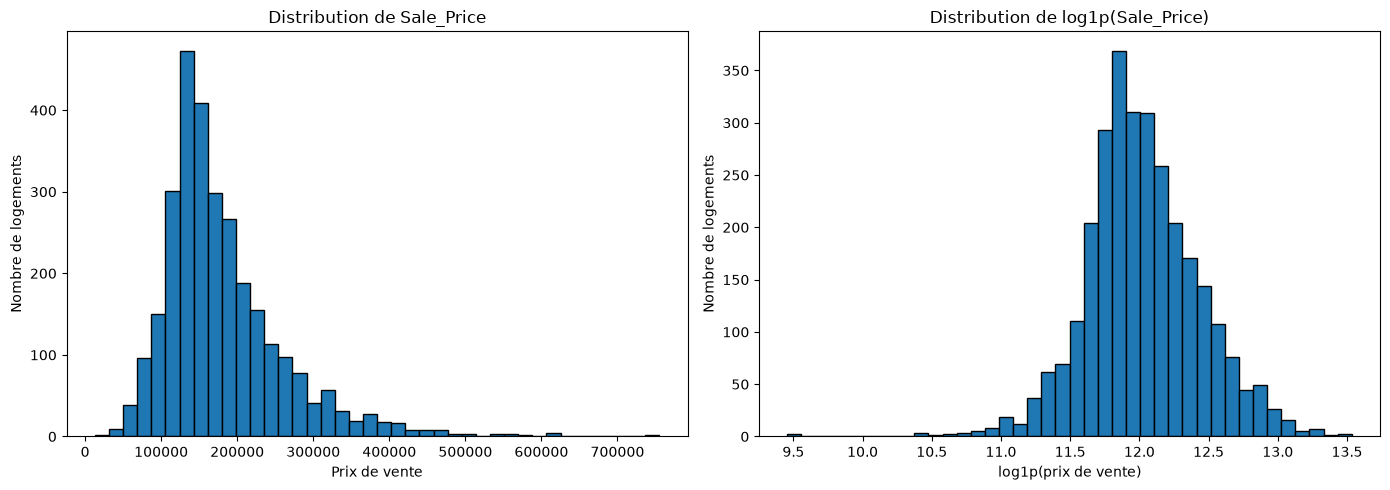

In [55]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].hist(
    df["Sale_Price"],
    bins=40,
    edgecolor="black"
)

axes[0].set_title(
    "Distribution de Sale_Price"
)

axes[0].set_xlabel(
    "Prix de vente"
)

axes[0].set_ylabel(
    "Nombre de logements"
)

axes[1].hist(
    np.log1p(df["Sale_Price"]),
    bins=40,
    edgecolor="black"
)

axes[1].set_title(
    "Distribution de log1p(Sale_Price)"
)

axes[1].set_xlabel(
    "log1p(prix de vente)"
)

axes[1].set_ylabel(
    "Nombre de logements"
)

plt.tight_layout()
plt.show()

In [ ]:
# Distributions asymétriques

# La variable `Sale_Price` présente généralement une asymétrie vers la droite :
# certains logements très chers sont éloignés de la majorité des observations.

# Cette asymétrie peut influencer une régression basée sur l'erreur quadratique.

# La transformation `log1p` réduit généralement l'influence des très grandes valeurs.
# La première expérience reste toutefois réalisée avec la cible originale afin de
# conserver une interprétation directe des métriques en dollars.

# Une transformation logarithmique de la cible pourra être testée séparément.

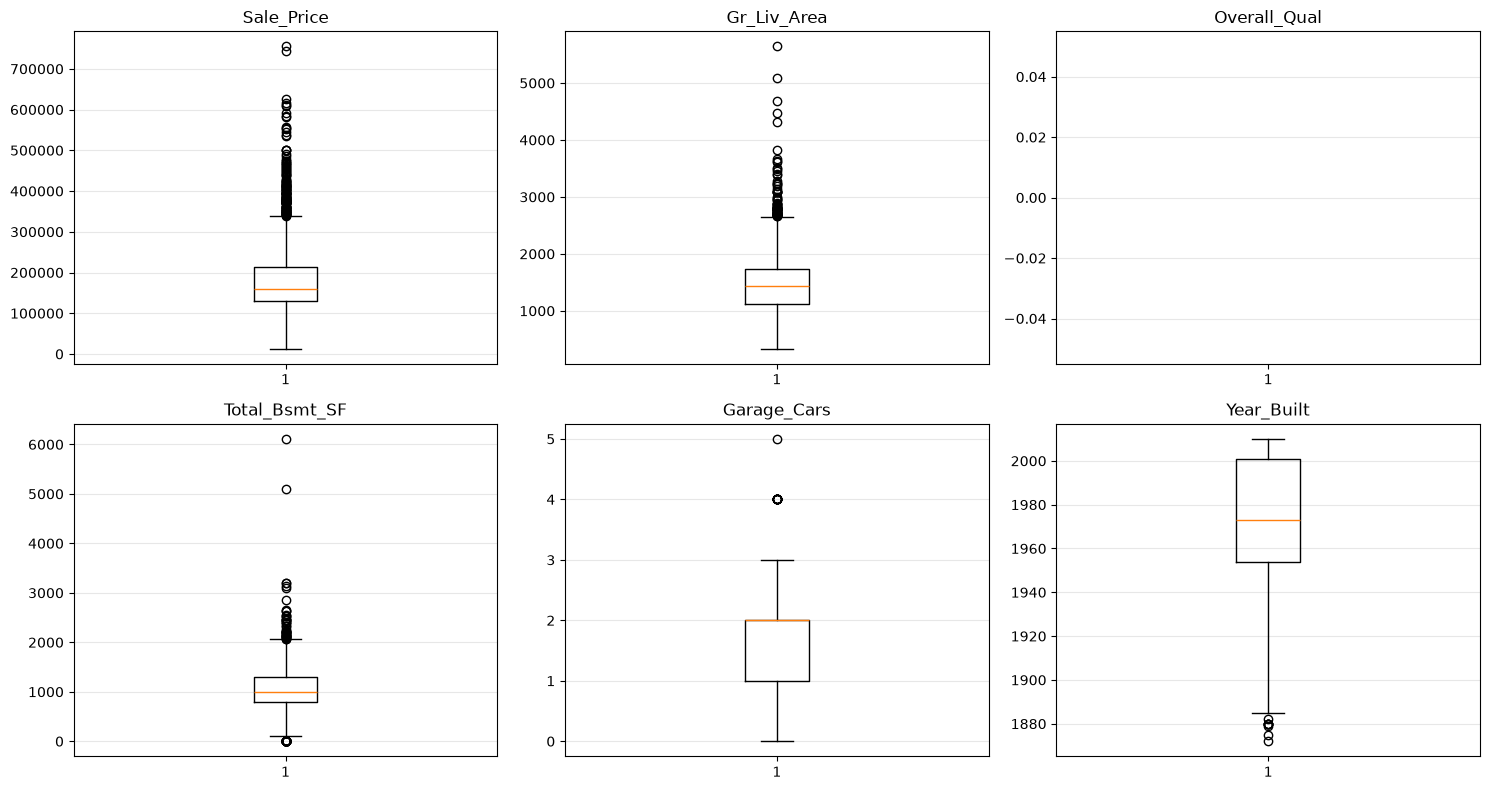

In [62]:
variables_influentes_numeriques = [
    "Sale_Price",
    "Gr_Liv_Area",
    "Overall_Qual",
    "Total_Bsmt_SF",
    "Garage_Cars",
    "Year_Built"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8)
)

axes = axes.flatten()

for axe, colonne in zip(
    axes,
    variables_influentes_numeriques
):
    valeurs = pd.to_numeric(
        df[colonne].astype(str),
        errors="coerce"
    ).dropna()

    axe.boxplot(
        valeurs
    )

    axe.set_title(colonne)
    axe.grid(
        axis="y",
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [57]:
df[
    variables_influentes
].describe().T

,count,mean,std,min,25%,50%,75%,max
Sale_Price,2930.0,180796.060068,79886.692357,12789.0,129500.0,160000.0,213500.00,755000.0
Gr_Liv_Area,2930.0,1499.690444,505.508887,334.0,1126.0,1442.0,1742.75,5642.0
Total_Bsmt_SF,2930.0,1051.255631,440.968018,0.0,793.0,990.0,1301.50,6110.0
Garage_Cars,2930.0,1.766212,0.761137,0.0,1.0,2.0,2.00,5.0
Year_Built,2930.0,1971.356314,30.245361,1872.0,1954.0,1973.0,2001.00,2010.0


In [ ]:
# Analyse des observations potentiellement influentes

# Les boxplots permettent d'identifier les valeurs extrêmes de plusieurs variables
# importantes comme `Sale_Price`, `Gr_Liv_Area`, `Total_Bsmt_SF` et `Year_Built`.

# Ces valeurs ne sont pas supprimées automatiquement. Une maison très grande ou
# très chère peut être une observation réelle et informative, même si elle est
# atypique statistiquement.

# Ces observations peuvent toutefois influencer fortement une régression linéaire.
# Leur impact sera étudié ultérieurement à partir des plus grandes erreurs absolues
# sur le jeu de validation.

# La décision retenue est donc de conserver les observations extrêmes pour la
# première expérience et de les analyser dans le stress test.

In [63]:
decisions_audit = pd.DataFrame([
    {
        "variable/groupe": "Identifiants",
        "problème": "Aucun identifiant détecté dans la version OpenML",
        "traitement": "Aucune suppression",
        "justification": (
            "La liste des identifiants détectés est vide."
        ),
        "appris_sur_TRAIN": "Non"
    },
    {
        "variable/groupe": "Valeurs manquantes",
        "problème": "Aucune valeur manquante détectée",
        "traitement": "Aucune correction effective",
        "justification": (
            "df.isna().sum().sum() retourne zéro."
        ),
        "appris_sur_TRAIN": "Non"
    },
    {
        "variable/groupe": "Variables numériques",
        "problème": "Valeurs éventuellement absentes dans de futures données",
        "traitement": "SimpleImputer par médiane",
        "justification": (
            "Pipeline robuste sans fuite de données."
        ),
        "appris_sur_TRAIN": "Oui"
    },
    {
        "variable/groupe": "Variables redondantes",
        "problème": "Corrélations élevées possibles",
        "traitement": "Conservation puis régularisation",
        "justification": (
            "Comparer LinearRegression, Ridge et Lasso."
        ),
        "appris_sur_TRAIN": "Oui"
    },
    {
        "variable/groupe": "Variables asymétriques",
        "problème": "Distributions dissymétriques",
        "traitement": "Analyse puis éventuelle transformation logarithmique",
        "justification": (
            "Limiter l'influence des grandes valeurs."
        ),
        "appris_sur_TRAIN": "À tester"
    },
    {
        "variable/groupe": "Valeurs extrêmes",
        "problème": "Observations potentiellement influentes",
        "traitement": "Conservation et analyse des erreurs",
        "justification": (
            "Une valeur extrême peut représenter une vraie maison atypique."
        ),
        "appris_sur_TRAIN": "Non"
    }
])

decisions_audit

,variable/groupe,problème,traitement,justification,appris_sur_TRAIN
0,Identifiants,Aucun identifiant détecté dans la version OpenML,Aucune suppression,La liste des identifiants détectés est vide.,Non
1,Valeurs manquantes,Aucune valeur manquante détectée,Aucune correction effective,df.isna().sum().sum() retourne zéro.,Non
2,Variables numériques,Valeurs éventuellement absentes dans de future...,SimpleImputer par médiane,Pipeline robuste sans fuite de données.,Oui
3,Variables redondantes,Corrélations élevées possibles,Conservation puis régularisation,"Comparer LinearRegression, Ridge et Lasso.",Oui
4,Variables asymétriques,Distributions dissymétriques,Analyse puis éventuelle transformation logarit...,Limiter l'influence des grandes valeurs.,À tester
5,Valeurs extrêmes,Observations potentiellement influentes,Conservation et analyse des erreurs,Une valeur extrême peut représenter une vraie ...,Non


## Protocole expérimental — 10 pts

Construisez TRAIN / VALIDATION / TEST. Le TEST doit rester invisible jusqu'à la décision finale.

Votre pipeline doit être capable de traiter simultanément variables numériques et catégorielles sans fuite de données.

**Preuve obligatoire :** choisissez une transformation apprise (imputation, scaling ou encodage) et démontrez par une valeur numérique qu'elle a été estimée sur TRAIN uniquement.

In [64]:
X = df.drop(
    columns=["Sale_Price"]
)

y = df["Sale_Price"]

X = X.drop(
    columns=colonnes_identifiants,
    errors="ignore"
)

X.shape, y.shape

((2930, 80), (2930,))

In [65]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42
)

In [66]:
pd.DataFrame({
    "jeu": [
        "TRAIN",
        "VALIDATION",
        "TEST"
    ],
    "observations": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],
    "pourcentage": [
        round(len(X_train) / len(df) * 100, 2),
        round(len(X_val) / len(df) * 100, 2),
        round(len(X_test) / len(df) * 100, 2)
    ]
})

,jeu,observations,pourcentage
0,TRAIN,1758,60.0
1,VALIDATION,586,20.0
2,TEST,586,20.0


In [ ]:
# Protocole expérimental

# La base est séparée en trois parties : TRAIN, VALIDATION et TEST.

# TRAIN sert à apprendre les paramètres du prétraitement et des modèles.

# VALIDATION sert à comparer les modèles et à choisir les hyperparamètres.

# TEST reste invisible jusqu'à la décision finale.

# La séparation utilise `random_state=42` afin de rendre les résultats reproductibles.
# Le jeu TEST sera utilisé une seule fois après le choix du modèle final.

In [67]:
colonnes_numeriques = X_train.select_dtypes(
    include=np.number
).columns.tolist()

colonnes_categorielles = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

len(colonnes_numeriques), len(colonnes_categorielles)

(34, 46)

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pipeline_numerique = Pipeline(steps=[
    (
        "imputation",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "normalisation",
        StandardScaler()
    )
])

In [70]:
pipeline_categoriel = Pipeline(steps=[
    (
        "imputation",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encodage",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [71]:
preprocesseur = ColumnTransformer(
    transformers=[
        (
            "numerique",
            pipeline_numerique,
            colonnes_numeriques
        ),
        (
            "categoriel",
            pipeline_categoriel,
            colonnes_categorielles
        )
    ],
    remainder="drop"
)

In [72]:
X_train_transforme = preprocesseur.fit_transform(
    X_train,
    y_train
)

X_train_transforme.shape

(1758, 343)

In [74]:
X_val_transforme = preprocesseur.transform(
    X_val
)

X_val_transforme.shape

(586, 343)

In [75]:
X_test_transforme = preprocesseur.transform(
    X_test
)

X_test_transforme.shape

(586, 343)

In [76]:
nouvelles_features = (
    preprocesseur.get_feature_names_out()
)

len(nouvelles_features)

343

In [77]:
nouvelles_features[:20]

array(['numerique__Lot_Frontage', 'numerique__Lot_Area',
       'numerique__Year_Built', 'numerique__Year_Remod_Add',
       'numerique__Mas_Vnr_Area', 'numerique__BsmtFin_SF_1',
       'numerique__BsmtFin_SF_2', 'numerique__Bsmt_Unf_SF',
       'numerique__Total_Bsmt_SF', 'numerique__First_Flr_SF',
       'numerique__Second_Flr_SF', 'numerique__Low_Qual_Fin_SF',
       'numerique__Gr_Liv_Area', 'numerique__Bsmt_Full_Bath',
       'numerique__Bsmt_Half_Bath', 'numerique__Full_Bath',
       'numerique__Half_Bath', 'numerique__Bedroom_AbvGr',
       'numerique__Kitchen_AbvGr', 'numerique__TotRms_AbvGrd'],
      dtype=object)

In [ ]:
# Transformation des variables

# La base contient 34 variables numériques et 46 variables catégorielles.

# Après transformation, les variables numériques sont imputées puis standardisées.
# Les variables catégorielles sont imputées puis encodées avec One-Hot Encoding.

# Le nombre de variables après transformation est supérieur au nombre initial,
# car chaque modalité catégorielle peut devenir une colonne binaire.

# Le même nombre de features est obtenu pour TRAIN, VALIDATION et TEST, ce qui
# permet d'appliquer le même modèle aux trois jeux.

In [79]:
mediane_train = (
    preprocesseur
    .named_transformers_["numerique"]
    .named_steps["imputation"]
    .statistics_
)

pd.Series(
    mediane_train,
    index=colonnes_numeriques
).head(10)

Lot_Frontage        62.0
Lot_Area          9375.0
Year_Built        1972.0
Year_Remod_Add    1992.0
Mas_Vnr_Area         0.0
BsmtFin_SF_1         3.0
BsmtFin_SF_2         0.0
Bsmt_Unf_SF        466.5
Total_Bsmt_SF      988.0
First_Flr_SF      1082.5
dtype: float64

In [80]:
categories_train = (
    preprocesseur
    .named_transformers_["categoriel"]
    .named_steps["encodage"]
    .categories_
)

[
    categories[:10]
    for categories in categories_train[:5]
]

[array(['Duplex_All_Styles_and_Ages', 'One_Story_1945_and_Older',
        'One_Story_1946_and_Newer_All_Styles',
        'One_Story_PUD_1946_and_Newer',
        'One_Story_with_Finished_Attic_All_Ages',
        'One_and_Half_Story_Finished_All_Ages',
        'One_and_Half_Story_PUD_All_Ages',
        'One_and_Half_Story_Unfinished_All_Ages',
        'PUD_Multilevel_Split_Level_Foyer', 'Split_Foyer'], dtype=object),
 array(['A_agr', 'C_all', 'Floating_Village_Residential',
        'Residential_High_Density', 'Residential_Low_Density',
        'Residential_Medium_Density'], dtype=object),
 array(['Grvl', 'Pave'], dtype=object),
 array(['Gravel', 'No_Alley_Access', 'Paved'], dtype=object),
 array(['Irregular', 'Moderately_Irregular', 'Regular',
        'Slightly_Irregular'], dtype=object)]

In [ ]:
# Preuve d'absence de fuite

# Le préprocesseur a été ajusté uniquement sur TRAIN avec `fit_transform`.

# Les médianes, les paramètres de normalisation et les catégories utilisées pour
# l'encodage ont donc été appris à partir de TRAIN uniquement.

# VALIDATION et TEST ont été transformés avec `transform`, sans recalculer les
# paramètres.

# Cette procédure évite d'utiliser indirectement les informations des jeux
# d'évaluation pendant l'apprentissage.

In [81]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

def evaluer_modele(
    modele,
    X_data,
    y_data
):
    predictions = modele.predict(
        X_data
    )

    mse = mean_squared_error(
        y_data,
        predictions
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        y_data,
        predictions
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

## Baseline et modèle linéaire — 10 pts

Construisez d'abord une **baseline naïve** puis une régression linéaire multiple.

Comparez-les sur VALIDATION avec **MSE, RMSE et R²**. Analysez au moins un graphique de résidus.

Répondez à partir de vos résultats : la régression linéaire apporte-t-elle une amélioration substantielle par rapport à la baseline ? Quelles structures restent visibles dans les résidus ?

In [ ]:
# Votre travail expérimental ici


## Polynomial challenge — 15 pts

Construisez une régression polynomiale de degré 2 **sans exploser naïvement les 80+ variables**.

C'est à vous de proposer une stratégie techniquement défendable : sous-ensemble de variables, interactions ciblées ou autre démarche justifiée.

Comparez TRAIN et VALIDATION. Quantifiez le nombre de features avant/après transformation.

**Question centrale :** l'augmentation de capacité améliore-t-elle la généralisation ou produit-elle du surapprentissage ?

In [ ]:
# Votre travail expérimental ici


## Ridge vs Lasso — 20 pts

Construisez Ridge et Lasso sur un pipeline cohérent. Étudiez plusieurs ordres de grandeur de `alpha`.

Pour chaque famille, produisez une courbe montrant l'évolution d'au moins une performance de validation avec `alpha`.

Pour Lasso, mesurez le nombre de coefficients exactement nuls. Pour Ridge, étudiez la norme des coefficients.

Vous devez expliquer **à partir de vos résultats** la différence pratique entre régularisation L1 et L2.

In [ ]:
# Votre travail expérimental ici


## Stress test — 10 pts

Votre modèle final doit subir un stress test.

Identifiez les **10 plus grandes erreurs absolues** sur VALIDATION. Pour au moins 3 maisons, comparez leurs caractéristiques à celles d'observations typiques et proposez une hypothèse expliquant l'erreur.

Une simple liste de prix réels/prédits ne suffit pas.

In [ ]:
# Votre travail expérimental ici


## Décision finale & TEST — 10 pts

Figez votre modèle et vos hyperparamètres **avant** d'ouvrir TEST. Évaluez une seule fois sur TEST.

Présentez MSE, RMSE, R² et une comparaison VALIDATION/TEST. Expliquez si la généralisation est cohérente avec ce que vous aviez anticipé.

Terminez par une recommandation technique de 10 lignes maximum.

In [ ]:
# Votre travail expérimental ici


## Reproductibilité & intégrité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.